# Where did the pandemic hit hardest?

**Question.** Notebook 01 estimated a national pandemic excess of ~245 000 deaths for England & Wales. That number averages over very different local experiences — London absorbed a sharp first wave, the Midlands and the north carried more of the cumulative load, and the South West got off comparatively lightly. This notebook breaks the same counterfactual down by region.

**Approach.** Use the per-region monthly series produced by `ons-mortality fetch-regional`, fit the same Bayesian linear model independently for each of the 9 English regions plus Wales, and rank regions by per-capita excess. Per-capita matters: London (≈9 M) and the North East (≈2.7 M) cannot be compared on absolute counts.

**Limits.** Same as notebook 01 — no age structure, no displacement adjustment. Population offset is applied *after* fitting (rates are computed at the end), not inside the regression. Regional population estimates ship with the repo as a small CSV; the bundled file is rounded and may lag the deaths series by a year.

## 0. Setup

Run once from the repository root if the regional CSV doesn't exist yet:

```bash
ons-mortality fetch-regional --start-year 2006 --end-year 2024
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ons_mortality.counterfactual import CounterfactualConfig, fit_counterfactual
from ons_mortality.population import load_regional_population

PROJECT_ROOT = Path('..').resolve()
REGIONAL_CSV = PROJECT_ROOT / 'data' / 'processed' / 'england_wales_regional_monthly_deaths.csv'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PANDEMIC_ONSET = pd.Timestamp('2020-03-01')

## 1. Load the regional series

One row per (region, month). 10 regions × 228 months = 2 280 rows. The same final-vs-provisional dedupe rule from notebook 01 applies: when a month appears in multiple workbooks, the more authoritative figure wins.

In [2]:
regional = (
    pd.read_csv(REGIONAL_CSV, parse_dates=['month_date'])
      .sort_values(['region_code', 'month_date'])
      .reset_index(drop=True)
)
regional.head()

,month_date,region_code,region_name,observed_deaths,edition_year,is_final,source_filename
0,2006-01-01,E12000001,North East,2570,2006,True,2006_publishedoutput200tcm772274163.xls
1,2006-02-01,E12000001,North East,2194,2006,True,2006_publishedoutput200tcm772274163.xls
2,2006-03-01,E12000001,North East,2517,2006,True,2006_publishedoutput200tcm772274163.xls
3,2006-04-01,E12000001,North East,2221,2006,True,2006_publishedoutput200tcm772274163.xls
4,2006-05-01,E12000001,North East,2381,2006,True,2006_publishedoutput200tcm772274163.xls


In [3]:
totals = (
    regional.groupby(['region_code', 'region_name'])['observed_deaths']
            .agg(['count', 'sum'])
            .rename(columns={'count': 'months', 'sum': 'total_deaths'})
            .sort_values('total_deaths', ascending=False)
)
totals

,,months,total_deaths
region_code,region_name,,
E12000008,South East,228,1535067
E12000002,North West,228,1374535
E12000009,South West,228,1068270
E12000006,East of England,228,1067196
E12000005,West Midlands,228,1041172
E12000003,Yorkshire and The Humber,228,993956
E12000007,London,228,957647
E12000004,East Midlands,228,852028
W92000004,Wales,228,630792


## 2. Small-multiples of the raw series

Same shape across regions — winter peaks, summer troughs, an obvious 2020 spike — but the *magnitudes* differ by 3–4x. London and the South East register the most absolute deaths simply because they're the largest. Already this tells us that any cross-regional comparison has to be per capita.

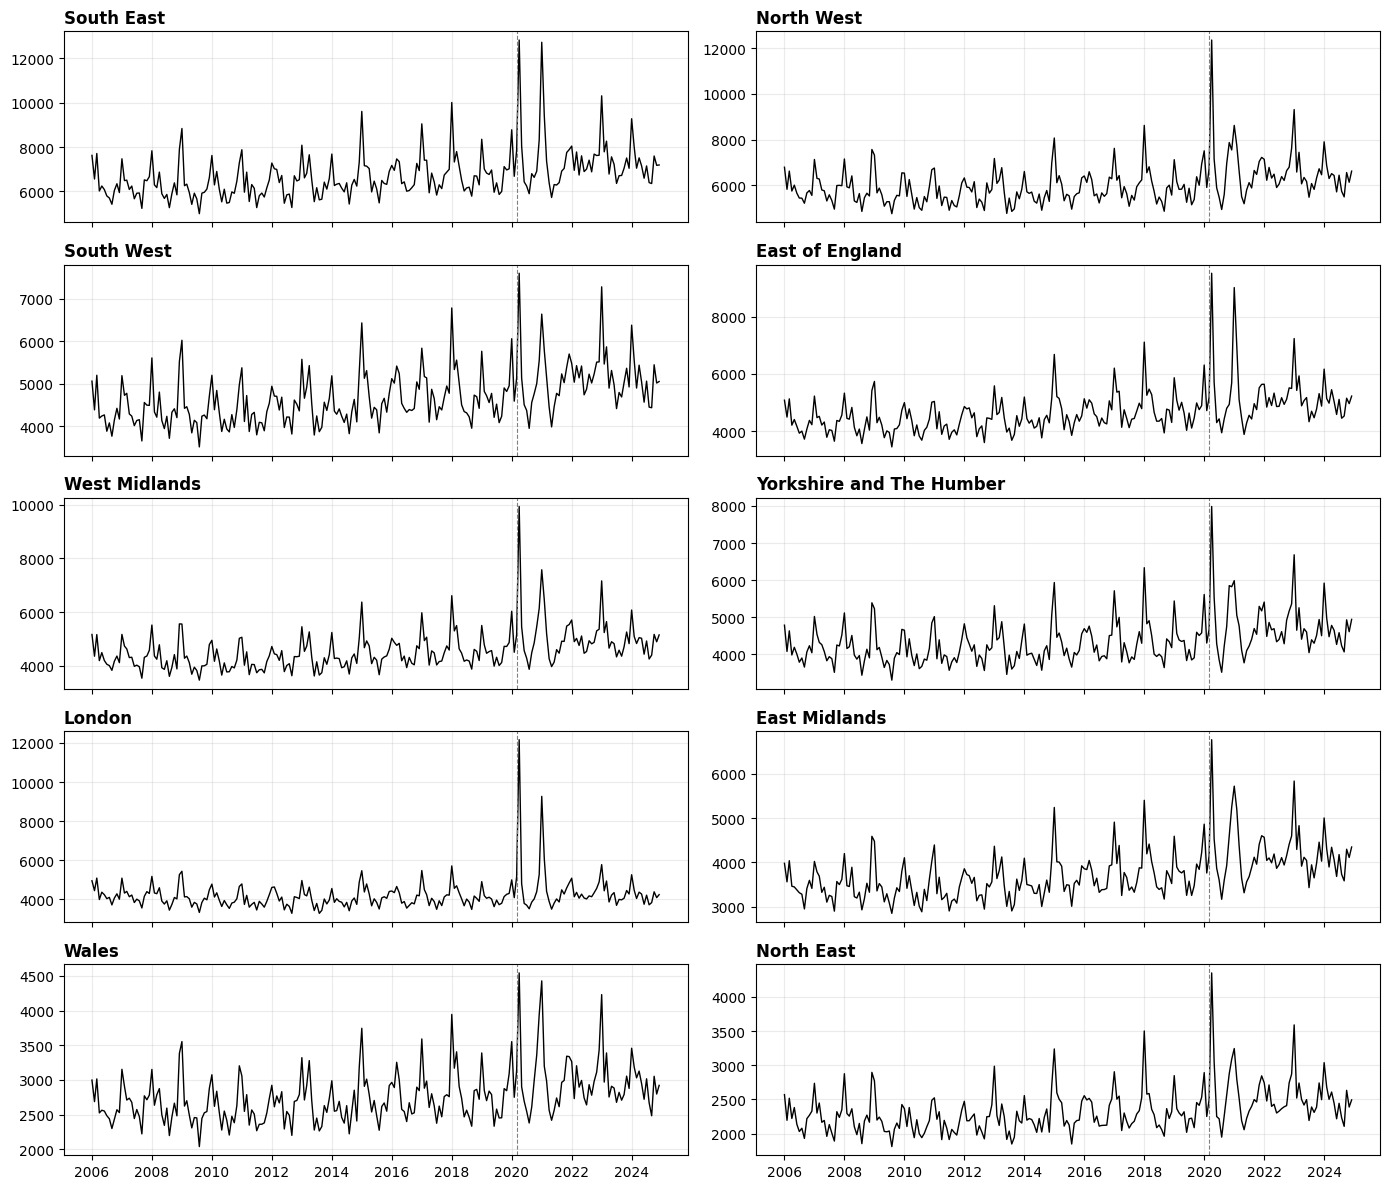

In [4]:
region_order = totals.reset_index()['region_name'].tolist()

fig, axes = plt.subplots(5, 2, figsize=(14, 12), sharex=True)
for ax, region_name in zip(axes.flat, region_order, strict=False):
    series = regional[regional['region_name'] == region_name]
    ax.plot(series['month_date'], series['observed_deaths'], color='black', linewidth=1.0)
    ax.axvline(PANDEMIC_ONSET, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(region_name, loc='left', fontweight='bold')
    ax.grid(alpha=0.25)
fig.tight_layout()

## 3. Crude regional death rates

Joining the regional deaths to ONS mid-year regional population estimates gives us deaths per 1 000 people for each region per year. This is the apples-to-apples comparison.

The pattern is striking and stable: **the North East and Wales sit ~10.5 deaths per 1 000 even pre-pandemic**, while **London sits ~5.5 per 1 000** — almost a 2× gap. That ordering reflects age structure (London is the youngest region by some margin; the North East and Wales are among the oldest) and is older than the pandemic. The pandemic shifts every line up by a few units in 2020 but doesn't change the rank order.

In [5]:
regional_pop = load_regional_population()

annual_regional = (
    regional.assign(year=regional['month_date'].dt.year)
            .groupby(['region_code', 'region_name', 'year'])['observed_deaths']
            .sum()
            .reset_index()
)

annual_with_pop = annual_regional.merge(
    regional_pop[['year', 'region_code', 'population_total']],
    on=['year', 'region_code'],
    how='inner',
)
annual_with_pop['cdr_per_1000'] = (
    annual_with_pop['observed_deaths'] / annual_with_pop['population_total'] * 1_000
)

cdr_pivot = annual_with_pop.pivot(
    index='year', columns='region_name', values='cdr_per_1000'
)[region_order]
cdr_pivot.round(2)

region_name,South East,North West,South West,East of England,West Midlands,Yorkshire and The Humber,London,East Midlands,Wales,North East
year,,,,,,,,,,
2006,9.19,10.19,10.10,9.25,9.71,9.63,6.82,9.58,10.48,10.53
2007,9.11,10.25,10.23,9.15,9.62,9.77,6.67,9.43,10.81,10.43
2008,9.12,10.24,10.30,9.27,9.63,9.74,6.64,9.56,10.75,10.66
2009,8.82,9.80,9.97,8.92,9.17,9.31,6.33,9.18,10.37,10.08
2010,8.88,9.73,9.90,8.97,9.17,9.26,6.24,9.14,10.41,9.95
2011,8.59,9.37,9.69,8.65,8.76,9.18,5.71,8.90,9.93,9.88
2012,8.80,9.61,9.93,8.92,9.02,9.32,5.80,9.10,10.25,10.09
2013,8.88,9.69,10.14,8.97,9.21,9.43,5.70,9.19,10.43,10.12
2014,8.71,9.54,9.77,8.90,9.05,9.18,5.64,9.05,10.15,10.24


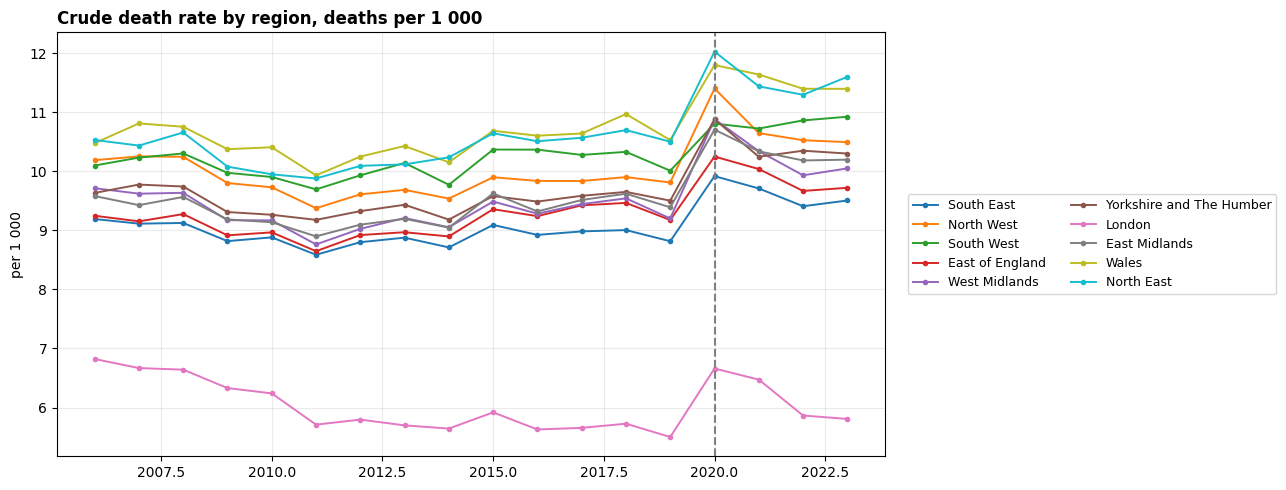

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
for region in cdr_pivot.columns:
    ax.plot(cdr_pivot.index, cdr_pivot[region], marker='o', markersize=3, linewidth=1.4, label=region)
ax.axvline(2020, color='gray', linestyle='--')
ax.set_title('Crude death rate by region, deaths per 1 000', loc='left', fontweight='bold')
ax.set_ylabel('per 1 000')
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()

## 4. A counterfactual per region

The model from notebook 01 doesn't care which series we feed it. Looping over regions and refitting gives us 10 independent counterfactuals — each with its own trend, seasonality, and posterior — which we can recombine afterwards.

Three Fourier harmonics, the same pre-2020 cutoff, 2 000 posterior draws per fit (sensitivity in notebook 01 showed the headline barely moves with sample count once you pass ~1 000).

In [7]:
config = CounterfactualConfig(
    pandemic_onset=str(PANDEMIC_ONSET.date()),
    n_posterior_samples=2_000,
    fourier_order=3,
    interval_mass=0.94,
    random_seed=42,
)

regional_results = []
for region_code, region_name in totals.reset_index()[['region_code', 'region_name']].values:
    series = (
        regional[regional['region_code'] == region_code]
        [['month_date', 'observed_deaths']]
        .reset_index(drop=True)
    )
    fit = fit_counterfactual(series, config=config)
    fit['region_code'] = region_code
    fit['region_name'] = region_name
    regional_results.append(fit)

all_fits = pd.concat(regional_results, ignore_index=True)
all_fits.tail()

,month_date,observed_deaths,counterfactual_median,counterfactual_lower,counterfactual_upper,excess_deaths,region_code,region_name
2275,2024-08-01,2232,2165.890148,1842.635323,2528.046864,66.109852,E12000001,North East
2276,2024-09-01,2105,2231.010619,1915.172366,2558.744239,0.000000,E12000001,North East
2277,2024-10-01,2633,2267.821711,1931.359000,2595.408158,365.178289,E12000001,North East
2278,2024-11-01,2388,2412.066242,2068.256434,2762.310196,0.000000,E12000001,North East
2279,2024-12-01,2493,2663.290427,2329.271389,3012.873040,0.000000,E12000001,North East


## 5. Annual excess by region

Aggregating the post-onset clipped excess to annual totals gives a 10×5 matrix (region × pandemic-era year). The North West contributes the largest share of cumulative excess in absolute terms, followed by the South East and London. 2020 carries the heaviest single-year load almost everywhere; the regions sustain positive annual excess through 2024 with no exception.

In [8]:
post = all_fits[all_fits['month_date'] >= PANDEMIC_ONSET].copy()
post['year'] = post['month_date'].dt.year

annual_excess = (
    post.groupby(['region_name', 'year'])['excess_deaths']
        .sum()
        .round()
        .astype(int)
        .unstack('year')
        .loc[region_order]
)
annual_excess['cumulative'] = annual_excess.sum(axis=1)
annual_excess.sort_values('cumulative', ascending=False)

year,2020,2021,2022,2023,2024,cumulative
region_name,,,,,,
North West,12942,8449,7104,7051,4698,40244
South East,9406,9010,5667,5986,3781,33850
London,11378,9026,3945,3970,2645,30964
West Midlands,9765,7169,4238,4689,3033,28894
Yorkshire and The Humber,8442,4231,4601,4411,3136,24821
East Midlands,6580,5126,3699,4096,2615,22116
East of England,6494,6602,3324,3474,1868,21762
South West,4140,4458,4474,4529,2852,20453
Wales,3912,3063,2083,2432,1560,13050


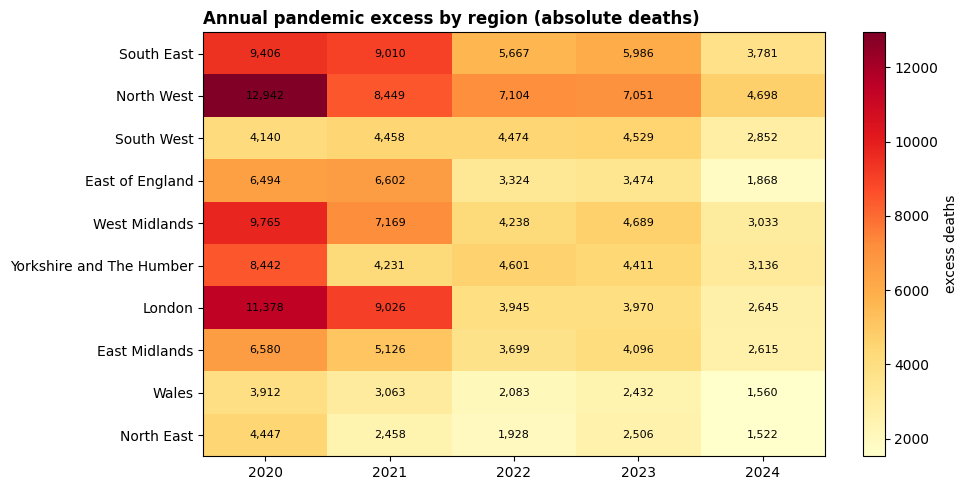

In [9]:
heatmap = annual_excess.drop(columns='cumulative')
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heatmap.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)
ax.set_title('Annual pandemic excess by region (absolute deaths)', loc='left', fontweight='bold')
fig.colorbar(im, ax=ax, label='excess deaths')
for (i, j), value in np.ndenumerate(heatmap.values):
    ax.text(j, i, f'{value:,}', ha='center', va='center', fontsize=8, color='black')
fig.tight_layout()

## 6. Per capita is the fair comparison

Absolute excess favours the big regions trivially — South East and London top the table because they're populous. Re-expressing cumulative excess as deaths per 1 000 of 2019 population reorders the table.

The picture flips: **the North West tops the per-capita ranking at ~5.5 excess deaths per 1 000**, with the West Midlands and North East close behind. London — top of the absolute table — sits **near the bottom per capita**, just above East of England. The national average is around 4.0 per 1 000, so the gap from top to bottom is about 60% of the mean.

In [10]:
pop_2019 = (
    regional_pop[regional_pop['year'] == 2019]
    .set_index('region_code')['population_total']
)
code_to_name = (
    regional[['region_code', 'region_name']].drop_duplicates().set_index('region_code')['region_name']
)

cumulative_by_region = (
    post.groupby('region_code')['excess_deaths'].sum().rename('cumulative_excess')
)
ranking = pd.concat([cumulative_by_region, pop_2019.rename('pop_2019')], axis=1).dropna()
ranking['region_name'] = ranking.index.map(code_to_name)
ranking['per_1000_2019_pop'] = ranking['cumulative_excess'] / ranking['pop_2019'] * 1_000
ranking_sorted = ranking.sort_values('per_1000_2019_pop', ascending=False)[
    ['region_name', 'cumulative_excess', 'pop_2019', 'per_1000_2019_pop']
]
ranking_sorted.assign(
    cumulative_excess=ranking_sorted['cumulative_excess'].round().astype(int),
    per_1000_2019_pop=ranking_sorted['per_1000_2019_pop'].round(2),
)

,region_name,cumulative_excess,pop_2019,per_1000_2019_pop
region_code,,,,
E12000002,North West,40244,7341000,5.48
E12000005,West Midlands,28894,5934000,4.87
E12000001,North East,12861,2670000,4.82
E12000004,East Midlands,22115,4838000,4.57
E12000003,Yorkshire and The Humber,24821,5530000,4.49
W92000004,Wales,13050,3152000,4.14
E12000008,South East,33849,9215000,3.67
E12000009,South West,20454,5625000,3.64
E12000006,East of England,21763,6234000,3.49


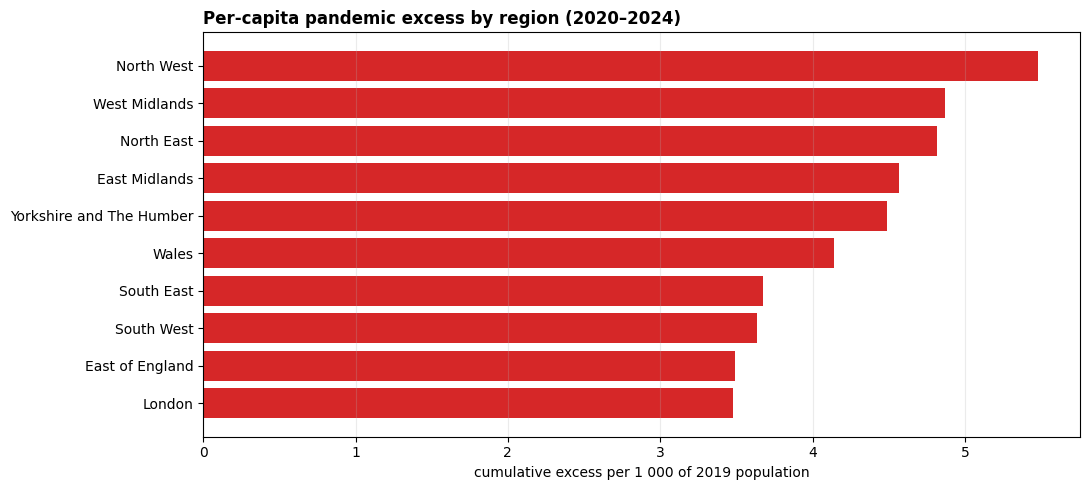

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(
    ranking_sorted['region_name'][::-1],
    ranking_sorted['per_1000_2019_pop'][::-1],
    color='C3',
)
ax.set_xlabel('cumulative excess per 1 000 of 2019 population')
ax.set_title('Per-capita pandemic excess by region (2020–2024)', loc='left', fontweight='bold')
ax.grid(alpha=0.25, axis='x')
fig.tight_layout()

## 7. The first wave: London absolute, the north + Midlands per capita

The COVID first wave in March–June 2020 has two distinct stories depending on which lens you use.

In **absolute** terms, London is unambiguous — ~9 900 excess deaths in four months, more than any other region. That fits the public memory of NHS Nightingale and the early-March hospital surge.

In **per-capita** terms, London drops to fourth: the North West (~1.18 per 1 000) and West Midlands (~1.17) edge it out, with the North East tied. The first wave wasn't uniquely a London phenomenon — it was a southern + northern + Midlands urban phenomenon, with rural regions (South West, Wales) clearly less affected.

In [12]:
first_wave_window = (post['month_date'] >= '2020-03-01') & (post['month_date'] <= '2020-06-01')
first_wave = (
    post[first_wave_window]
    .groupby('region_code')['excess_deaths'].sum()
    .rename('first_wave_excess')
)
first_wave_per_1000 = (first_wave / pop_2019 * 1_000).rename('per_1000')

first_wave_table = pd.concat([first_wave, first_wave_per_1000], axis=1).dropna()
first_wave_table['region_name'] = first_wave_table.index.map(code_to_name)
first_wave_table = first_wave_table.sort_values('per_1000', ascending=False)[
    ['region_name', 'first_wave_excess', 'per_1000']
]
first_wave_table.assign(
    first_wave_excess=first_wave_table['first_wave_excess'].round().astype(int),
    per_1000=first_wave_table['per_1000'].round(2),
)

,region_name,first_wave_excess,per_1000
region_code,,,
E12000002,North West,8643,1.18
E12000005,West Midlands,6946,1.17
E12000007,London,9930,1.11
E12000001,North East,2954,1.11
E12000003,Yorkshire and The Humber,5276,0.95
E12000006,East of England,5718,0.92
E12000004,East Midlands,4227,0.87
E12000008,South East,8011,0.87
W92000004,Wales,2145,0.68


## 8. The Alpha-variant wave (Nov 2020–Feb 2021) was diffuse

The "second wave" in popular memory is the December 2020 surge driven by the Alpha (Kent) variant, which emerged in the South East and spread fast. Excess deaths in the Nov 2020–Feb 2021 window confirm a different pattern from the first wave:

- **West Midlands, East of England, Wales, East Midlands, London** lead per capita (0.82–0.92 per 1 000).
- **The North East and Yorkshire are noticeably lower** for this specific window (~0.65) — their second-wave peak was earlier (autumn 2020) and slightly outside this slice.
- **South West stays low**, as it did in the first wave.

The lesson: regional excess depends sharply on which months you bracket. A Sep 2020–Mar 2021 window would put the north back near the top; the Nov–Feb slice catches the Alpha wave specifically.

In [13]:
second_wave_window = (post['month_date'] >= '2020-11-01') & (post['month_date'] <= '2021-02-01')
second_wave = (
    post[second_wave_window]
    .groupby('region_code')['excess_deaths'].sum()
    .rename('second_wave_excess')
)
second_wave_per_1000 = (second_wave / pop_2019 * 1_000).rename('per_1000')

second_wave_table = pd.concat([second_wave, second_wave_per_1000], axis=1).dropna()
second_wave_table['region_name'] = second_wave_table.index.map(code_to_name)
second_wave_table = second_wave_table.sort_values('per_1000', ascending=False)[
    ['region_name', 'second_wave_excess', 'per_1000']
]
second_wave_table.assign(
    second_wave_excess=second_wave_table['second_wave_excess'].round().astype(int),
    per_1000=second_wave_table['per_1000'].round(2),
)

,region_name,second_wave_excess,per_1000
region_code,,,
E12000005,West Midlands,5463,0.92
E12000006,East of England,5466,0.88
W92000004,Wales,2678,0.85
E12000004,East Midlands,4068,0.84
E12000007,London,7268,0.82
E12000008,South East,7231,0.78
E12000002,North West,5692,0.78
E12000001,North East,1726,0.65
E12000003,Yorkshire and The Humber,3505,0.63


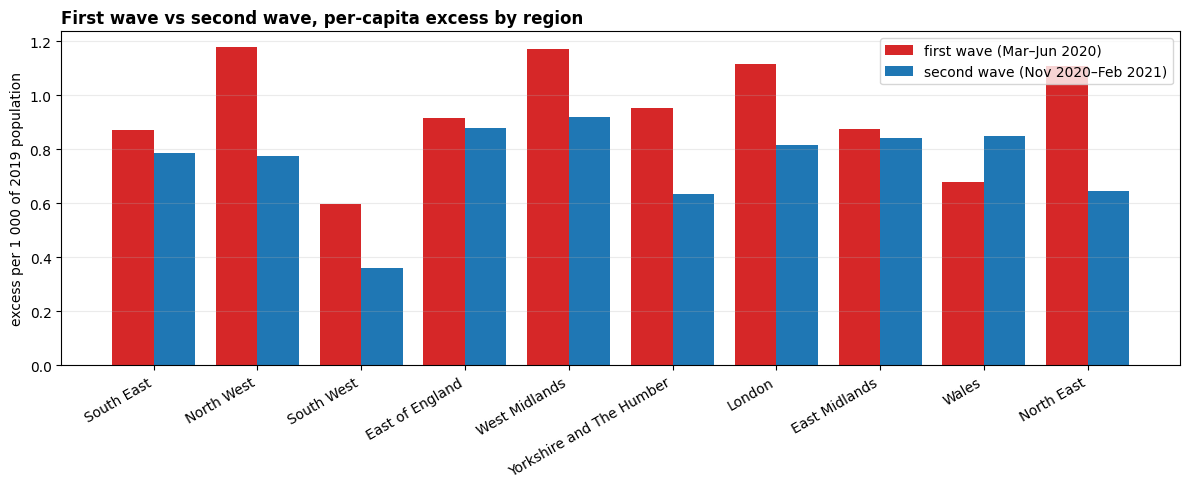

In [14]:
wave_compare = pd.DataFrame({
    'first_wave': first_wave_per_1000,
    'second_wave': second_wave_per_1000,
}).dropna()
wave_compare['region_name'] = wave_compare.index.map(code_to_name)
wave_compare = wave_compare.set_index('region_name').loc[region_order]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(wave_compare))
width = 0.4
ax.bar(x - width / 2, wave_compare['first_wave'],  width, label='first wave (Mar–Jun 2020)',  color='C3')
ax.bar(x + width / 2, wave_compare['second_wave'], width, label='second wave (Nov 2020–Feb 2021)', color='C0')
ax.set_xticks(x)
ax.set_xticklabels(wave_compare.index, rotation=30, ha='right')
ax.set_ylabel('excess per 1 000 of 2019 population')
ax.set_title('First wave vs second wave, per-capita excess by region', loc='left', fontweight='bold')
ax.legend()
ax.grid(alpha=0.25, axis='y')
fig.tight_layout()

## 9. Summary

- The 9 English regions plus Wales sum to the national figure within ~0.2% (the discrepancy is non-resident deaths, included in `K04000001` from the 2023 edition onwards). Total cumulative excess across regions: **~246 000**, matching notebook 01's national headline.
- **Pre-pandemic crude death rate is structurally higher in the North East and Wales (10.5+ per 1 000), structurally lower in London (~5.5 per 1 000).** That ordering reflects age structure and is older than the pandemic; the pandemic amplifies it but doesn't create it.
- **Cumulative per-capita excess (2020–2024)** ranks: North West (5.48) > West Midlands (4.87) > North East (4.82) > East Midlands (4.57) > Yorkshire (4.49) > Wales (4.14) > South East (3.67) > South West (3.64) > East of England (3.49) > London (3.48). London — top of the absolute table — sits **near the bottom per capita**.
- **First wave (Mar–Jun 2020):** London leads in absolute deaths but ties for fourth per capita. North West and West Midlands top the per-capita ranking; rural regions are clearly less affected.
- **Alpha-variant wave (Nov 2020–Feb 2021):** diffuse — West Midlands, East of England, Wales, East Midlands all lead per capita, with London and South East close behind. Northern regions appear lower in this specific window because their second-wave peak fell slightly earlier (autumn 2020).
- The big takeaway: **the absolute and per-capita rankings disagree sharply**. Reporting absolute excess flatters London and the South East; reporting per-capita excess flatters the South West and East of England. Both tables are correct — pick the one that answers the question being asked.

**What to do next.**

- Repeat at sub-region level (local authority) — the workbooks already include LA rows.
- Apply age-standardisation per region: the South West skews older, London younger, and ASMR would correct for that.
- Overlay a UK regional shapefile to produce a choropleth instead of a heatmap (requires `geopandas`).